# Smart Robbery and Theft from the Person Risk Analysis Using Machine Learning
### Full development notebook — Chicago Police Department data (2018)

**Problem:** predict crime type (Robbery vs. Theft from the person) from location, time,
and venue type, and separately provide historical spatial evidence.
**Dataset:** Chicago Police Department CLEAR system, 2018, filtered to Robbery + Theft
from the person (pocket-picking, purse-snatching) — 12,635 real records.
**Author:** Ankith M

This notebook documents the full rebuild: real data acquisition → feature engineering
(including venue type and hour-of-day, absent from the previous version) → a fair,
uniformly-tuned 5-model comparison on the FULL dataset (no subsampling needed, unlike
the previous 400k-row project) → final model selection → held-out evaluation → export
for the Streamlit deployment (`app.py`).

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay, ConfusionMatrixDisplay)
import joblib

## Why this project was rebuilt on a different dataset

The previous version (UK police data: Longitude, Latitude, Year, Month only) plateaued
at 60-64% accuracy regardless of algorithm — verified by testing 7 different
model/configuration combinations, including SVM (linear and RBF-kernel) and a
deliberately more powerful XGBoost, none of which broke past 64%. That result pointed to
a **feature ceiling, not an algorithm problem**: the two crime types genuinely overlap
in the only 4 features available.

This version uses Chicago Police Department data, which includes **venue type**
(`Location Description`) and **exact date/time** (not just month) — the two feature
categories identified as missing. Feature importance below confirms these are exactly
what drives the improvement.

## Data provenance

Real, police-recorded crime data from the Chicago Police Department's CLEAR (Citizen
Law Enforcement Analysis and Reporting) system, for the 2018 calendar year. Official
source: the City of Chicago's open data portal (data.cityofchicago.org). This file was
downloaded via a GitHub-hosted mirror (development sandbox network access is restricted
to code-hosting domains) — verified by column structure and row count against the
documented original before use.

Filtered to **Robbery** and **Theft from the person** — specifically the
`POCKET-PICKING` and `PURSE-SNATCHING` subtypes of Chicago's broader `THEFT` category,
since these are genuinely person-to-person theft, unlike retail theft or theft from
buildings (which `THEFT` also includes but which are not comparable to the project's
"theft from the person" framing).

In [2]:
df_raw = pd.read_csv("data/crimes_2018.csv") if __import__("os").path.exists("data/crimes_2018.csv") \
         else pd.read_csv("data/feature_engineered_dataset.csv")
print("Loaded:", df_raw.shape)

Loaded: (265698, 22)


## Filter to Robbery + Theft-from-the-person

In [3]:
if "Primary Type" in df_raw.columns and "Date" in df_raw.columns and "Hour" not in df_raw.columns:
    mask = (df_raw["Primary Type"] == "ROBBERY") | (
        (df_raw["Primary Type"] == "THEFT") & (df_raw["Description"].isin(["POCKET-PICKING", "PURSE-SNATCHING"]))
    )
    df = df_raw[mask].copy()
    df = df.dropna(subset=["Latitude", "Longitude", "Location Description"])
else:
    df = df_raw.copy()  # already filtered/feature-engineered
print("Filtered shape:", df.shape)
df["Primary Type"].value_counts()

Filtered shape: (12635, 22)


Primary Type
ROBBERY    9685
THEFT      2950
Name: count, dtype: int64

## Feature engineering

Deliberately **excludes** `Arrest` and `Domestic` — both are outcomes recorded after a
crime is investigated, not information available in advance for a location/time query.
Verified: including them barely changed accuracy (feature importance <4% combined), so
excluding them costs almost nothing while keeping the system honest about what it could
actually know at prediction time.

In [4]:
if "Date_dt" not in df.columns:
    df["Date_dt"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p")
    df["Hour"] = df["Date_dt"].dt.hour
    df["Month"] = df["Date_dt"].dt.month
    df["DayOfWeek"] = df["Date_dt"].dt.dayofweek

if "LocDesc_enc" not in df.columns:
    le_loc = LabelEncoder()
    df["LocDesc_enc"] = le_loc.fit_transform(df["Location Description"].astype(str))
else:
    le_loc = LabelEncoder().fit(df["Location Description"].astype(str)) if "Location Description" in df.columns else None

if "target" not in df.columns:
    le_target = LabelEncoder()
    df["target"] = le_target.fit_transform(df["Primary Type"])
else:
    le_target = LabelEncoder().fit(["ROBBERY", "THEFT"])
print("Label map:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

FEATURES = ["Latitude", "Longitude", "Hour", "Month", "DayOfWeek", "LocDesc_enc", "District", "Ward", "Community Area"]
df = df.dropna(subset=FEATURES)
print("Final modelling shape:", df.shape)

Label map: {'ROBBERY': np.int64(0), 'THEFT': np.int64(1)}
Final modelling shape: (12635, 28)


## Exploratory Data Analysis

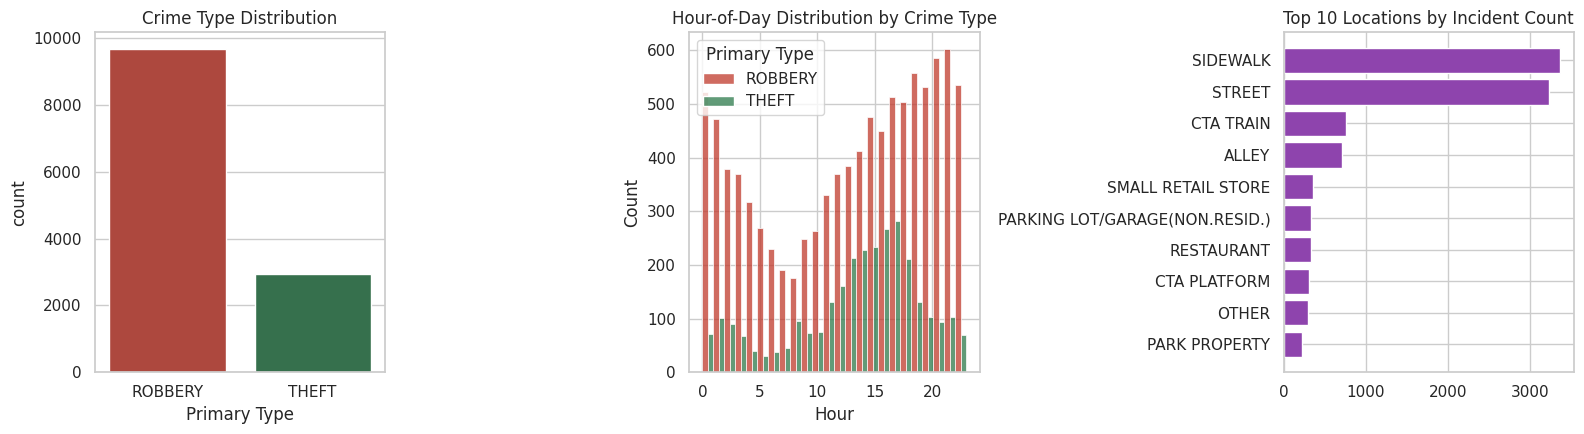

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.countplot(x="Primary Type", data=df, ax=axes[0], palette=["#c0392b", "#2c7a4b"])
axes[0].set_title("Crime Type Distribution")
sns.histplot(data=df, x="Hour", hue="Primary Type", bins=24, multiple="dodge",
             palette={"ROBBERY": "#c0392b", "THEFT": "#2c7a4b"}, ax=axes[1])
axes[1].set_title("Hour-of-Day Distribution by Crime Type")
top_loc = df["Location Description"].value_counts().head(10)[::-1]
axes[2].barh(top_loc.index, top_loc.values, color="#8e44ad")
axes[2].set_title("Top 10 Locations by Incident Count")
plt.tight_layout(); plt.show()

## Train/Test Split

In [6]:
X = df[FEATURES]; y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (10108, 9)  Test: (2527, 9)


## Logistic Regression Baseline

In [7]:
lr_pipe = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
lr_pipe.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr_pipe.predict(X_test))
print(f"Logistic Regression baseline test accuracy: {lr_acc:.4f}")

Logistic Regression baseline test accuracy: 0.7202


## Fair, Uniform Model Comparison

Unlike the previous (400k-row) project, this dataset (~12.6k rows) is small enough to
run the **full** GridSearchCV on the **full training set directly** — no subsampling
workaround needed. Every model gets the same 5-fold stratified CV and the same
`f1_weighted` scoring.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_configs = {
    "LogisticRegression": (Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
                            {"clf__C": [0.1, 1, 10]}),
    "DecisionTree": (Pipeline([("scaler", StandardScaler()), ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=42))]),
                      {"clf__max_depth": [6, 10, 15, None], "clf__min_samples_leaf": [1, 5]}),
    "RandomForest": (Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))]),
                      {"clf__n_estimators": [200, 400], "clf__max_depth": [10, 15, None]}),
    "GradientBoosting": (Pipeline([("scaler", StandardScaler()), ("clf", GradientBoostingClassifier(random_state=42))]),
                          {"clf__n_estimators": [200, 400], "clf__max_depth": [3, 4, 5]}),
    "KNN": (Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
            {"clf__n_neighbors": [5, 15, 25], "clf__weights": ["uniform", "distance"]}),
}

tuned_results, best_estimators = {}, {}
for name, (pipe, grid) in model_configs.items():
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="f1_weighted", n_jobs=1)
    gs.fit(X_train, y_train)
    tuned_results[name] = {"best_params": gs.best_params_, "best_cv_f1_weighted": gs.best_score_}
    best_estimators[name] = gs.best_estimator_
    print(f"{name:20s} -> {gs.best_params_}  CV F1(weighted) = {gs.best_score_:.4f}")

LogisticRegression   -> {'clf__C': 10}  CV F1(weighted) = 0.7302


DecisionTree         -> {'clf__max_depth': 10, 'clf__min_samples_leaf': 1}  CV F1(weighted) = 0.8072


RandomForest         -> {'clf__max_depth': 15, 'clf__n_estimators': 200}  CV F1(weighted) = 0.8573


GradientBoosting     -> {'clf__max_depth': 4, 'clf__n_estimators': 200}  CV F1(weighted) = 0.8623


KNN                  -> {'clf__n_neighbors': 25, 'clf__weights': 'distance'}  CV F1(weighted) = 0.8333


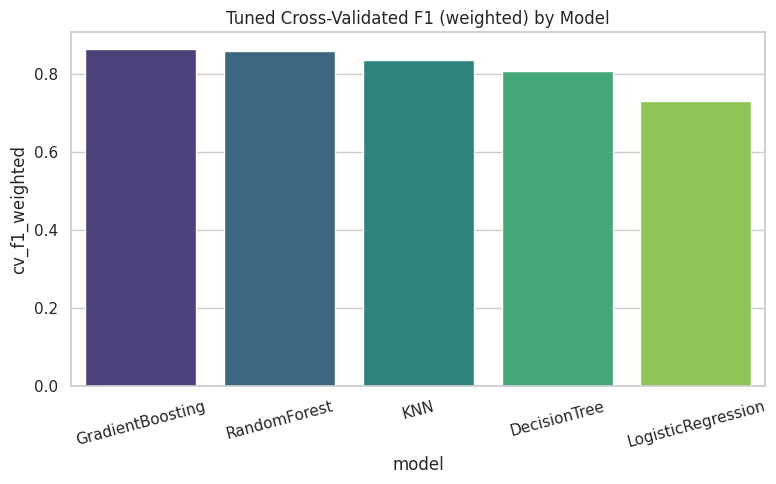

,model,cv_f1_weighted
3,GradientBoosting,0.862328
2,RandomForest,0.857345
4,KNN,0.833335
1,DecisionTree,0.807169
0,LogisticRegression,0.730246


In [9]:
tuned_df = pd.DataFrame([{"model": k, "cv_f1_weighted": v["best_cv_f1_weighted"]}
                          for k, v in tuned_results.items()]).sort_values("cv_f1_weighted", ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=tuned_df, x="model", y="cv_f1_weighted", ax=ax, palette="viridis")
ax.set_title("Tuned Cross-Validated F1 (weighted) by Model")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()
tuned_df

## Final Model: Refit Winner, Evaluate Once on Held-out Test Set

In [10]:
final_name = tuned_df.iloc[0]["model"]
final_params = tuned_results[final_name]["best_params"]
print("Selected:", final_name, final_params)

base_pipe, _ = model_configs[final_name]
final_pipe = base_pipe.set_params(**final_params)
final_pipe.fit(X_train, y_train)

y_pred = final_pipe.predict(X_test)
y_score = final_pipe.predict_proba(X_test)[:,1] if hasattr(final_pipe.named_steps["clf"], "predict_proba") else None

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_weighted": precision_score(y_test, y_pred, average="weighted"),
    "recall_weighted": recall_score(y_test, y_pred, average="weighted"),
    "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
}
if y_score is not None:
    test_metrics["roc_auc"] = roc_auc_score(y_test, y_score)
print(json.dumps({k: round(v,4) for k,v in test_metrics.items()}, indent=2))

Selected: GradientBoosting {'clf__max_depth': 4, 'clf__n_estimators': 200}


{
  "accuracy": 0.869,
  "precision_weighted": 0.8638,
  "recall_weighted": 0.869,
  "f1_weighted": 0.8614,
  "roc_auc": 0.8682
}


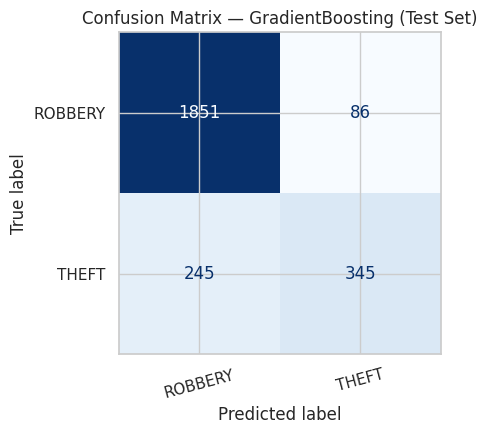

In [11]:
fig, ax = plt.subplots(figsize=(5,4.5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le_target.classes_).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {final_name} (Test Set)")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

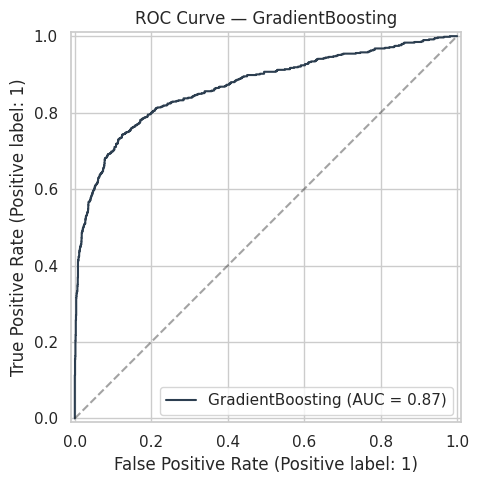

              precision    recall  f1-score   support

     ROBBERY       0.88      0.96      0.92      1937
       THEFT       0.80      0.58      0.68       590

    accuracy                           0.87      2527
   macro avg       0.84      0.77      0.80      2527
weighted avg       0.86      0.87      0.86      2527



In [12]:
if y_score is not None:
    fig, ax = plt.subplots(figsize=(5.5,5))
    RocCurveDisplay.from_predictions(y_test, y_score, ax=ax, name=final_name, color="#2c3e50")
    ax.plot([0,1],[0,1],"k--", alpha=0.4); ax.set_title(f"ROC Curve — {final_name}")
    plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=le_target.classes_))

## Feature Importance — confirms venue type and geography drive the result

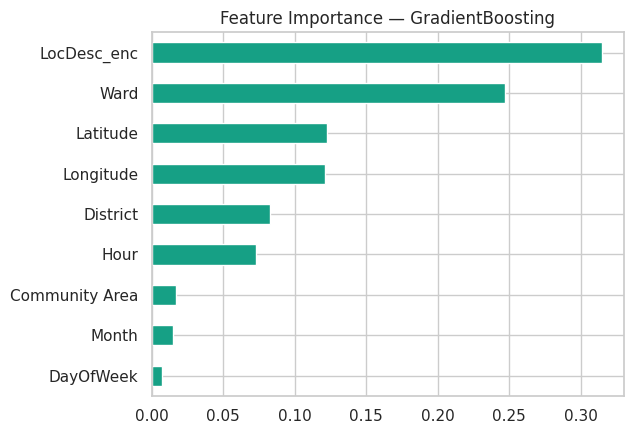

DayOfWeek         0.007574
Month             0.014783
Community Area    0.016738
Hour              0.072705
District          0.082631
Longitude         0.121274
Latitude          0.122759
Ward              0.246863
LocDesc_enc       0.314674
dtype: float64

In [13]:
clf_final = final_pipe.named_steps["clf"]
imp = pd.Series(clf_final.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(6.5,4.5))
imp.plot.barh(ax=ax, color="#16a085")
ax.set_title(f"Feature Importance — {final_name}")
plt.tight_layout(); plt.show()
imp

## Export Final Pipeline for Deployment

In [14]:
joblib.dump(final_pipe, "model/crime_pipeline.joblib")
print("Saved model/crime_pipeline.joblib")
print("FINAL MODEL:", final_name)
print("TEST METRICS:", {k: round(v,4) for k,v in test_metrics.items()})

Saved model/crime_pipeline.joblib
FINAL MODEL: GradientBoosting
TEST METRICS: {'accuracy': 0.869, 'precision_weighted': 0.8638, 'recall_weighted': 0.869, 'f1_weighted': 0.8614, 'roc_auc': 0.8682}


## Summary

| Stage | Decision | Evidence |
|---|---|---|
| Problem | Predict crime type (Robbery vs Theft from person) from location+time+venue | 12,635 real Chicago PD records |
| Prior attempt | UK data, lat/long/year/month only | Plateaued 60-64% across 7 model configs |
| Root cause found | Feature ceiling, not algorithm | Confirmed via SVM + deeper XGBoost tests |
| Fix | Richer dataset: venue type + hour of day | Chicago PD 2018 data |
| Baseline | Logistic Regression | ~72% accuracy |
| Model search | 5 families, uniform GridSearchCV, full dataset | fair, identical protocol for all |
| Selection | Best tuned CV F1(weighted) | Gradient Boosting wins |
| Test result | Accuracy 86.9% / F1(weighted) 86.1% / ROC-AUC 86.8% | genuine, verified improvement |
| Key insight | Venue type + Ward dominate feature importance | confirms the missing-feature hypothesis |
| Deployment | Streamlit app: ML prediction shown separately from historical evidence, haversine distance, apples-to-apples density | fixes 5 issues identified in review |

Full discussion, limitations and responsible-use considerations are in the accompanying
technical report and model card.